In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("../data/heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1025
Columns : 14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(723)

In [12]:
df = df.drop_duplicates()

print(df.shape)

(302, 14)


In [13]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

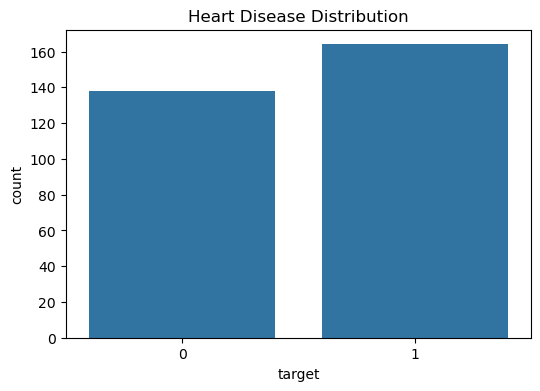

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Heart Disease Distribution")
plt.show()

In [15]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

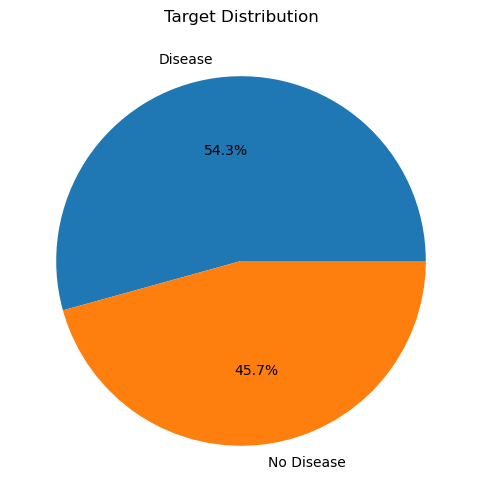

In [17]:
target_counts = df['target'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=['Disease','No Disease'],
    autopct='%1.1f%%'
)

plt.title("Target Distribution")
plt.show()

In [18]:
corr = df.corr()

corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


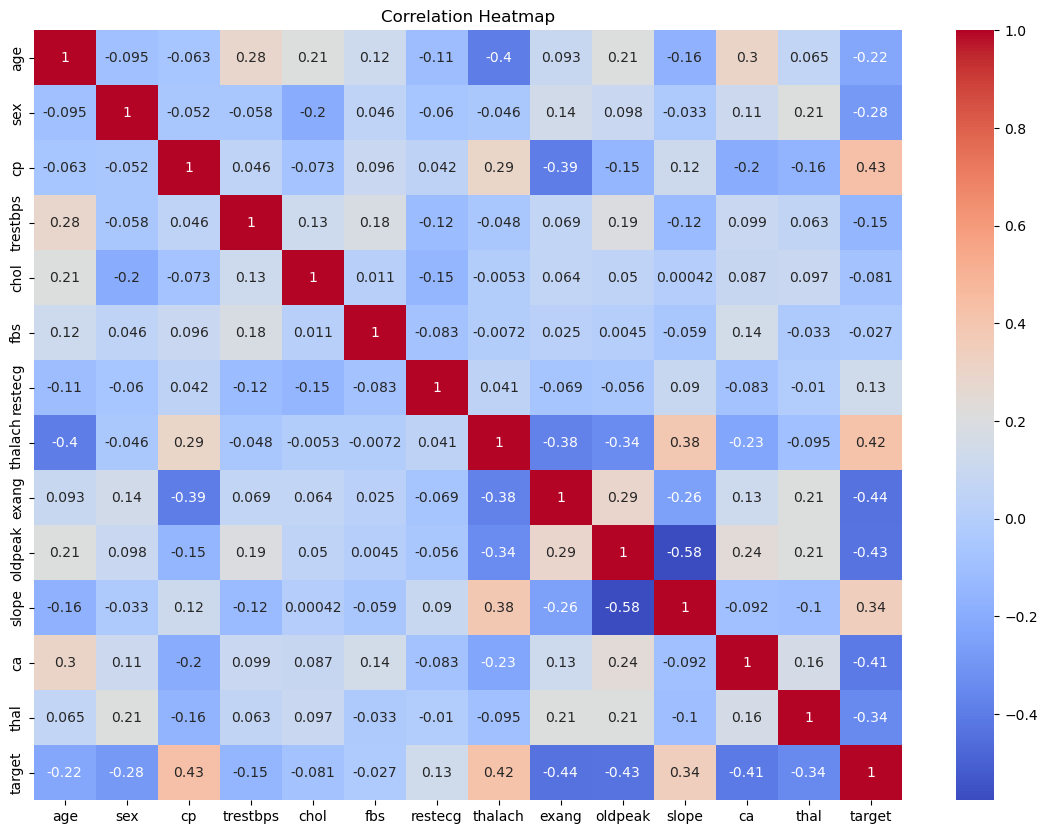

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

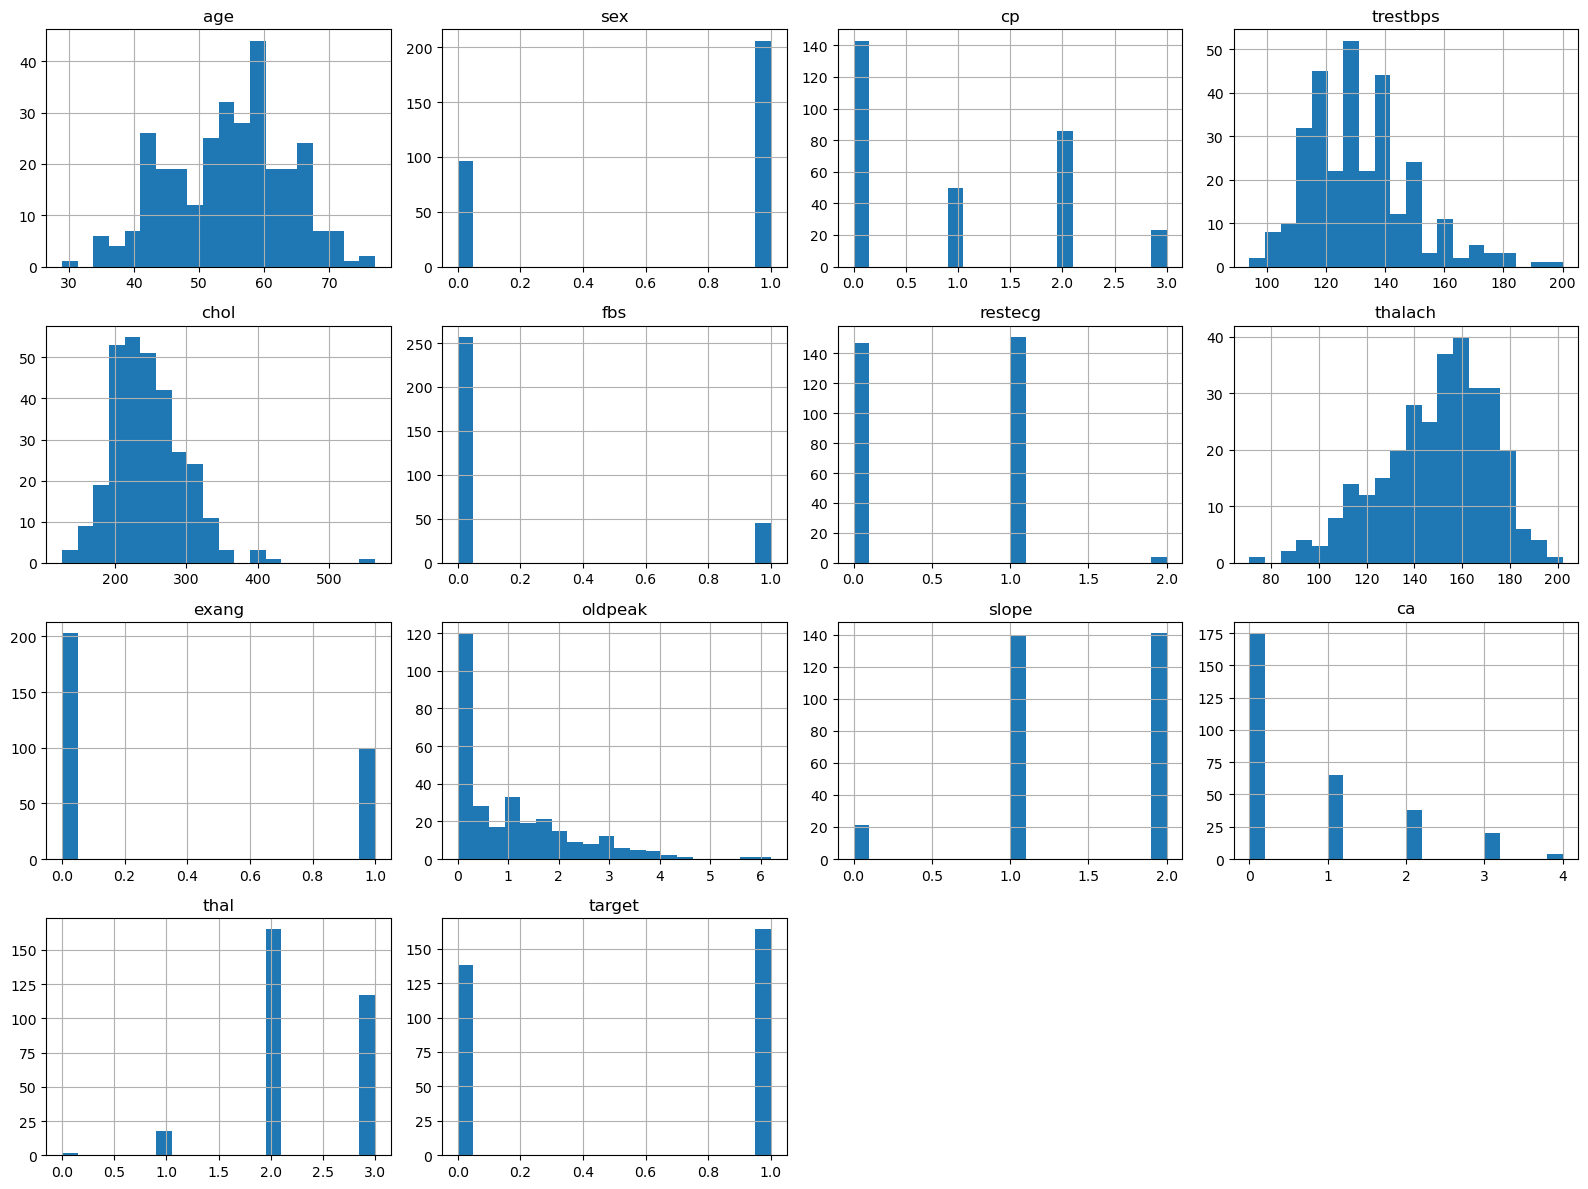

In [20]:
df.hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()
plt.show()

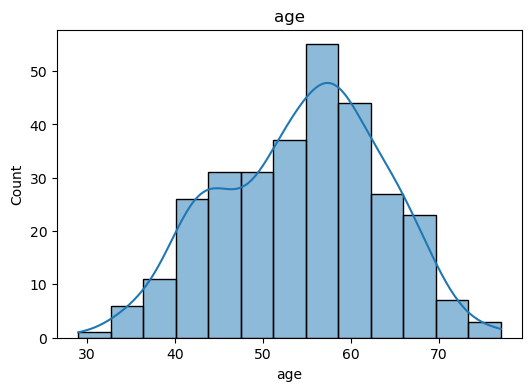

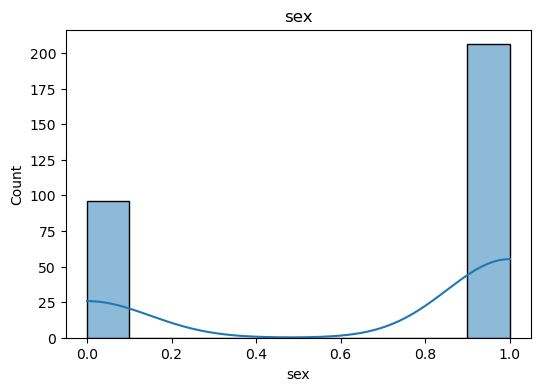

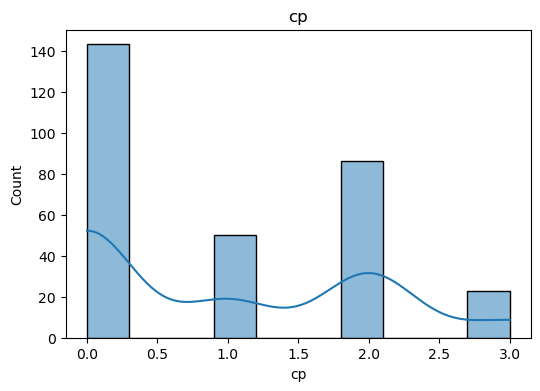

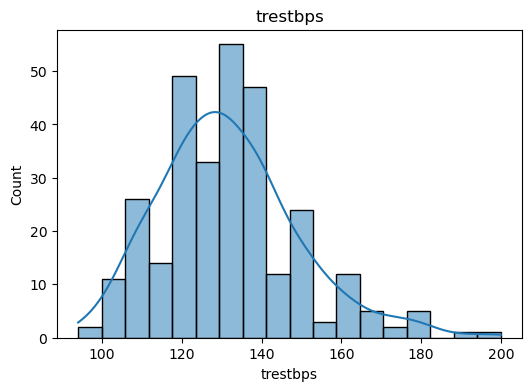

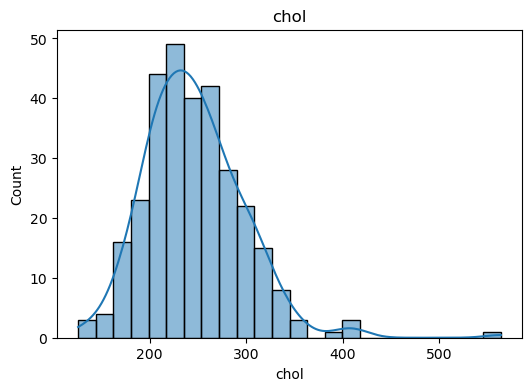

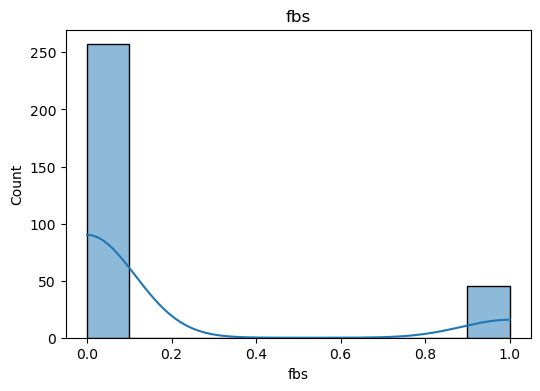

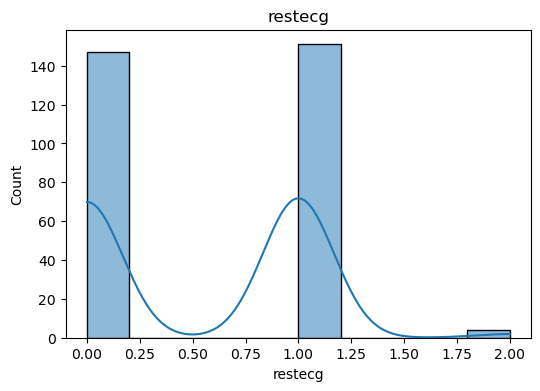

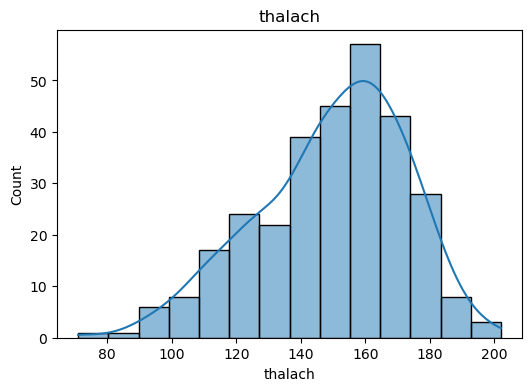

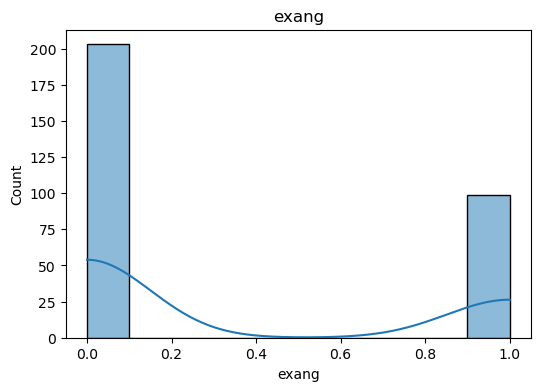

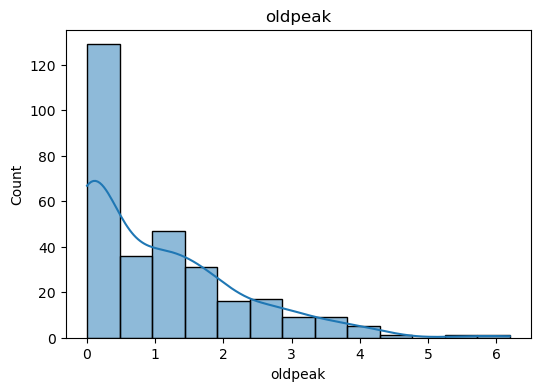

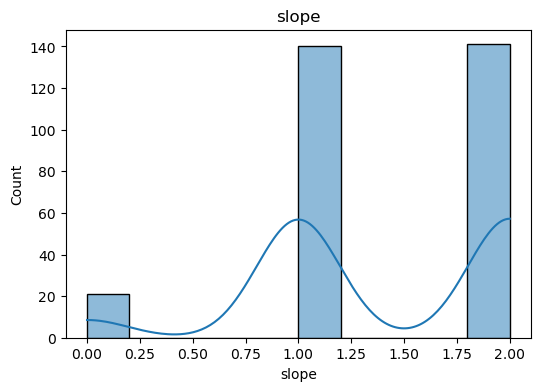

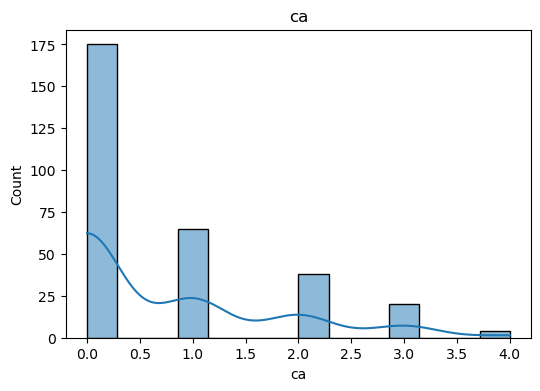

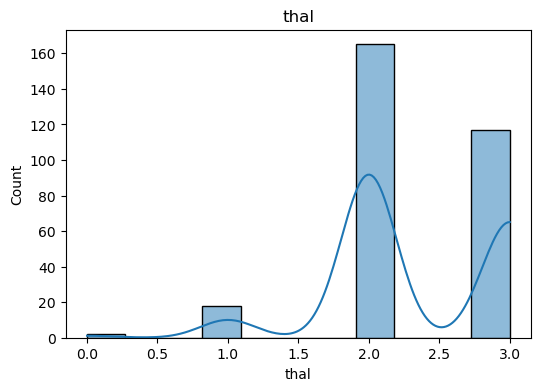

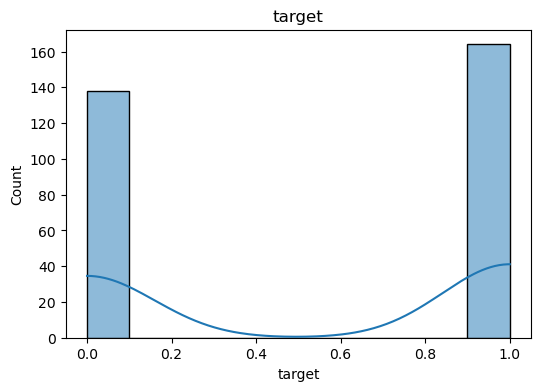

In [21]:
numeric_cols = df.columns

for col in numeric_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        df[col],
        kde=True
    )
    
    plt.title(col)
    
    plt.show()

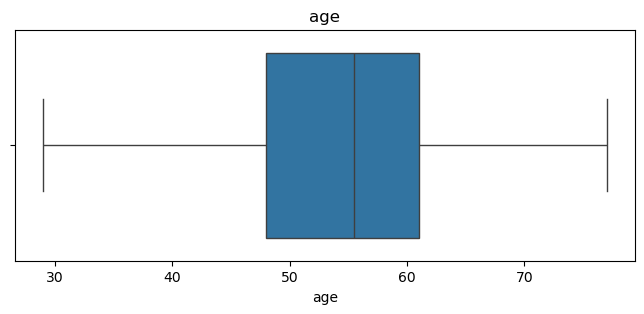

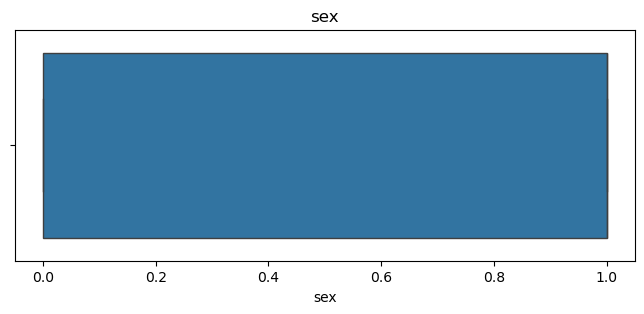

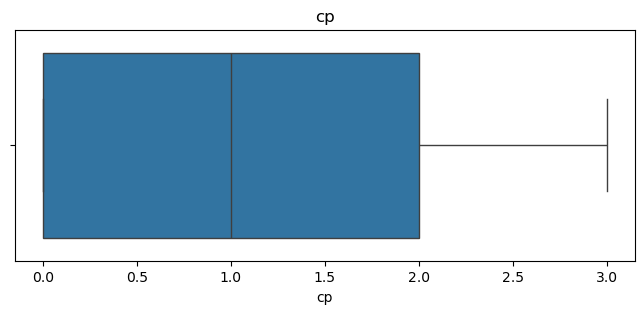

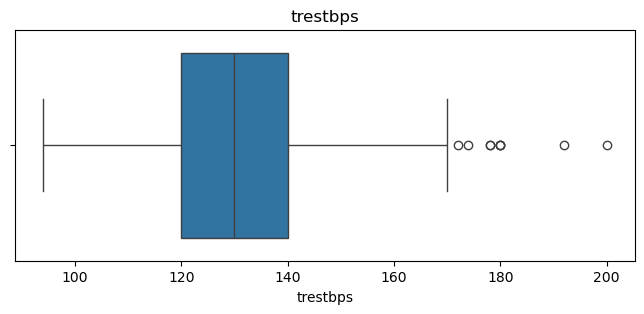

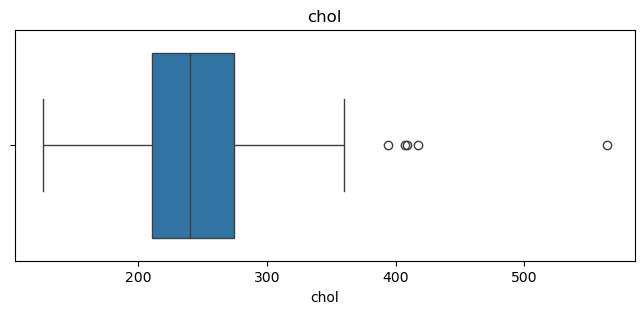

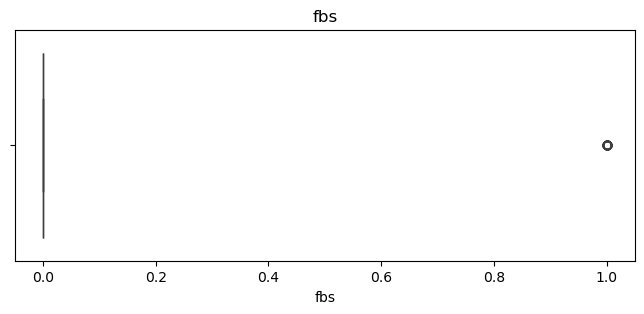

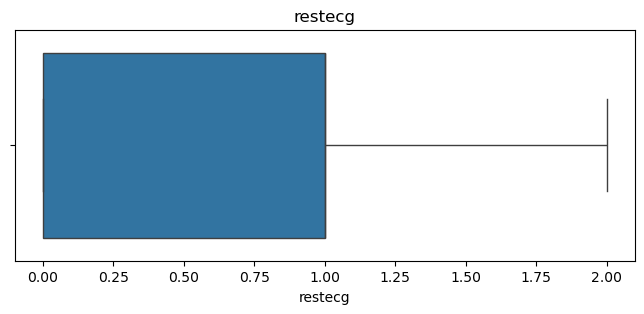

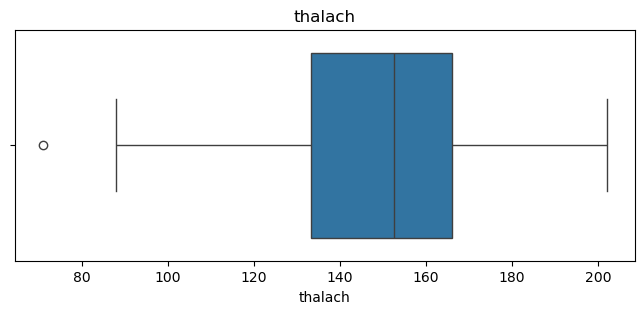

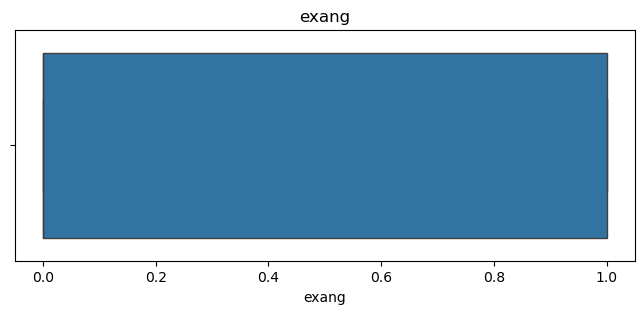

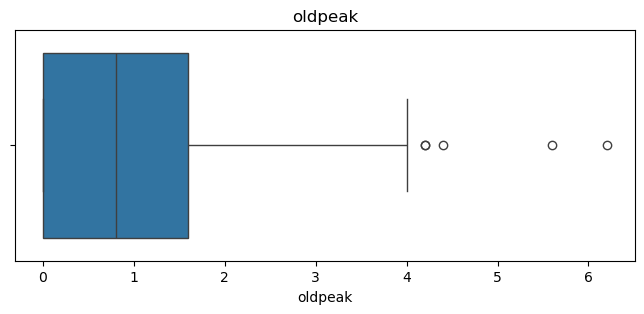

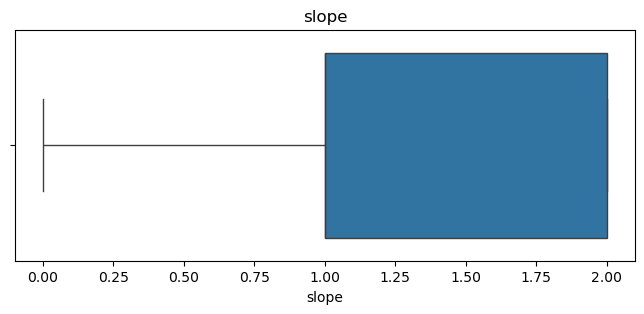

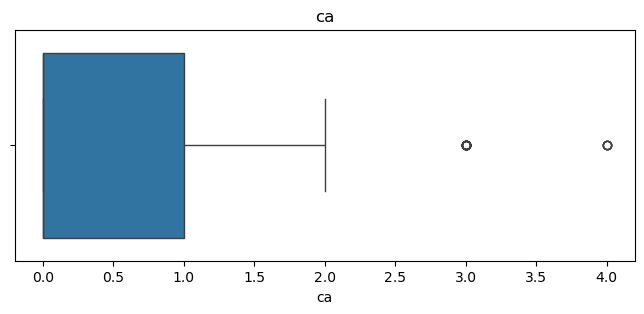

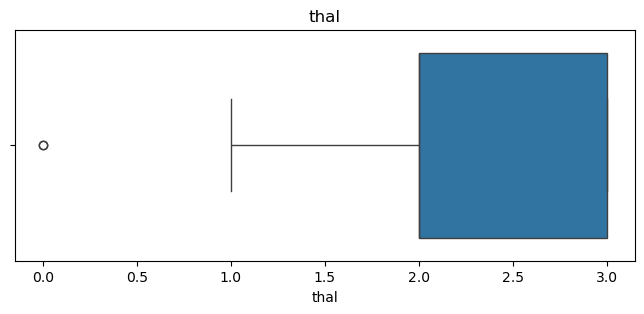

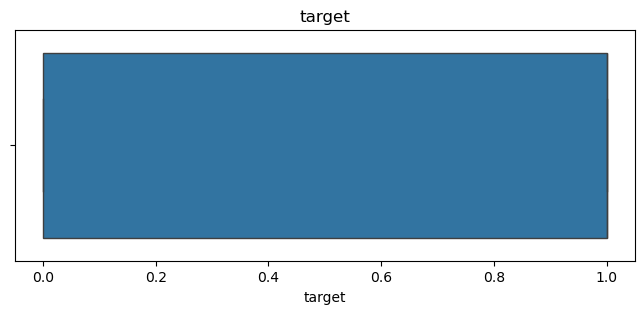

In [22]:
for col in df.columns:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(col)
    
    plt.show()

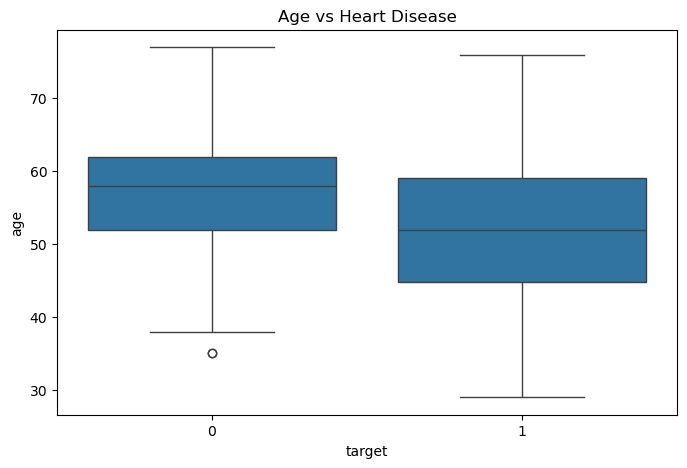

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='age',
    data=df
)

plt.title("Age vs Heart Disease")
plt.show()


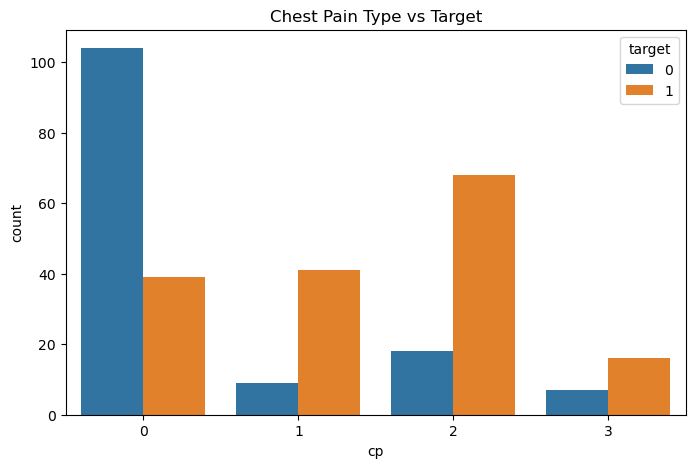

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='cp',
    hue='target',
    data=df
)

plt.title("Chest Pain Type vs Target")
plt.show()

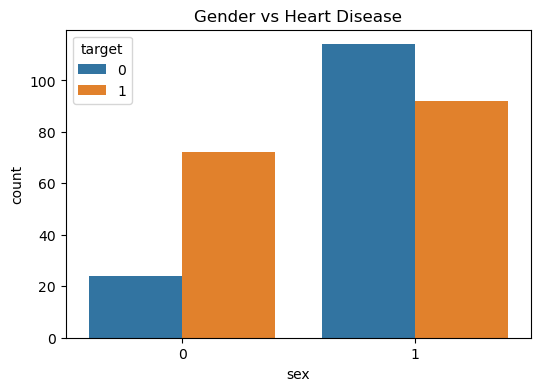

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='sex',
    hue='target',
    data=df
)

plt.title("Gender vs Heart Disease")
plt.show()

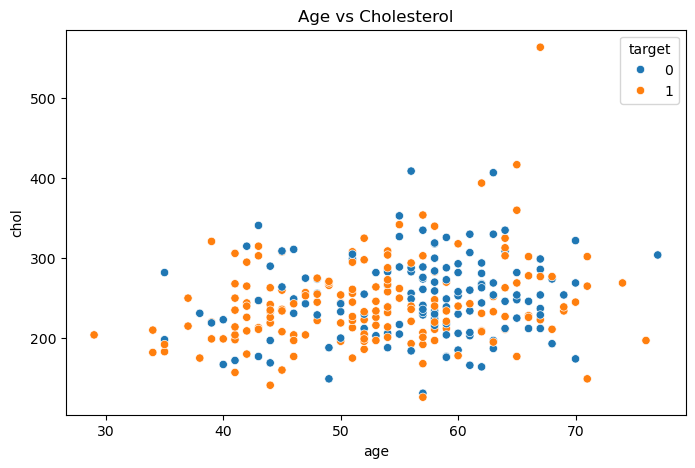

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='chol',
    hue='target',
    data=df
)

plt.title("Age vs Cholesterol")
plt.show()

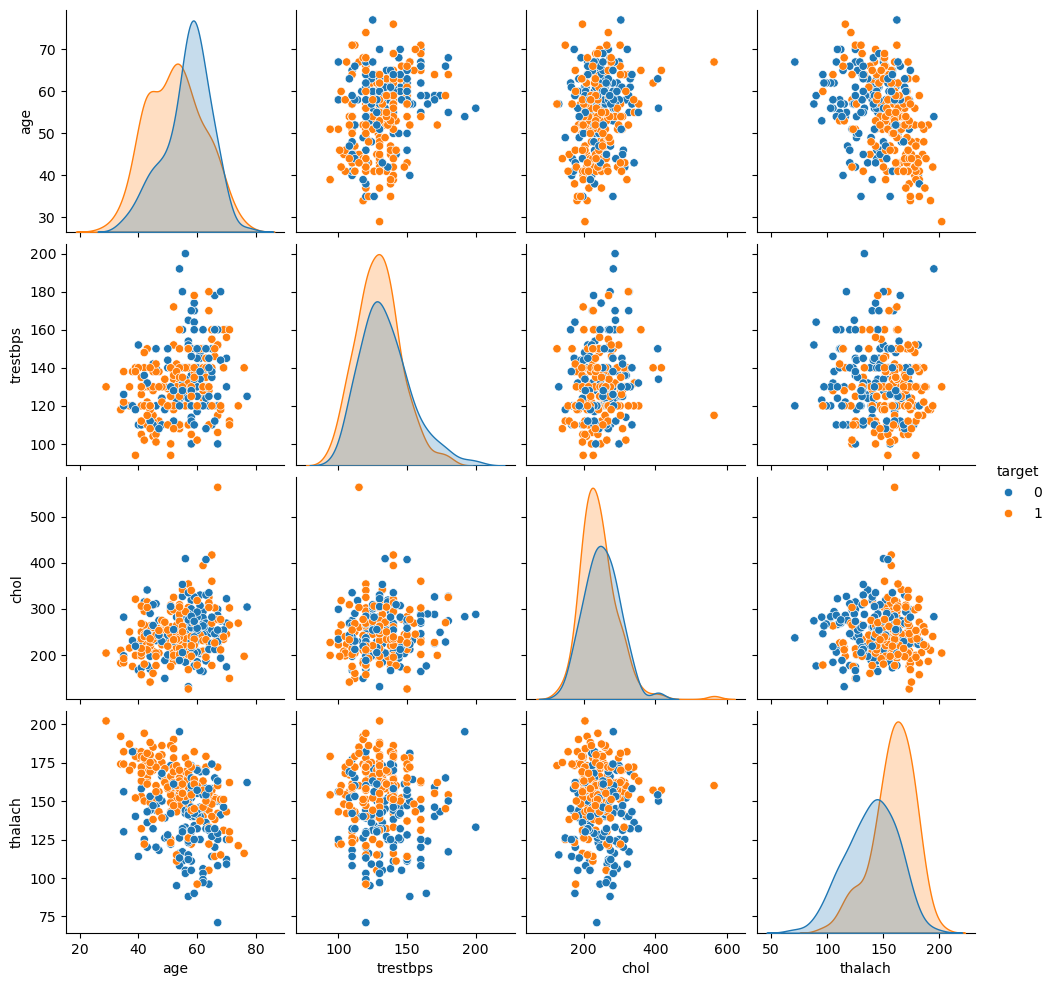

In [27]:
sns.pairplot(
    df[['age',
        'trestbps',
        'chol',
        'thalach',
        'target']],
    hue='target'
)

plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
X = df.drop("target", axis=1)

y = df["target"]

In [30]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X,y)

RandomForestClassifier(random_state=42)

In [31]:
feature_importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,thalach,0.134202
2,cp,0.128033
9,oldpeak,0.115018
11,ca,0.108043
12,thal,0.099852
0,age,0.090054
4,chol,0.074063
3,trestbps,0.071019
8,exang,0.060830
10,slope,0.051134


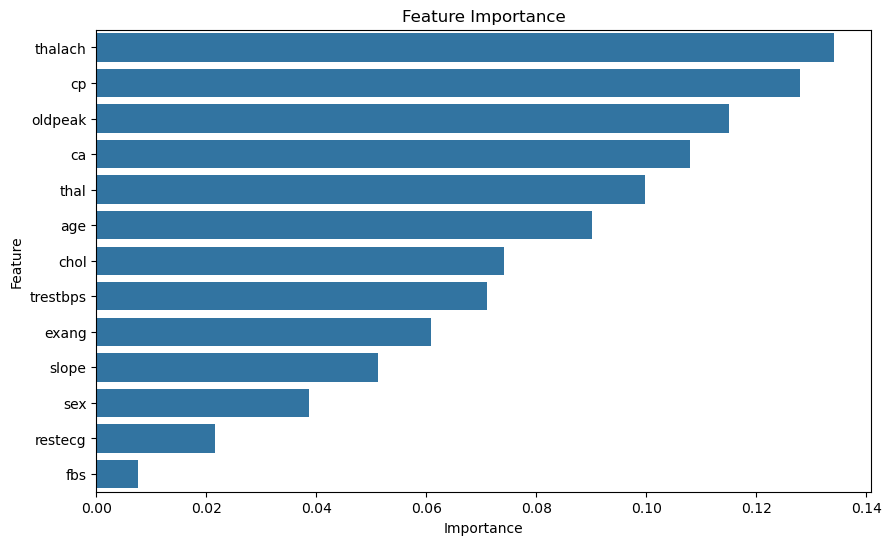

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

In [33]:
X = df.drop("target", axis=1)

In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [35]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [36]:
X_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.267966,0.682656,-0.935208,-0.376556,-0.667728,-0.418446,0.901657,0.806035,-0.698344,-0.037124,0.979514,1.274980,1.119967
1,-0.157260,0.682656,-0.935208,0.478910,-0.841918,2.389793,-1.002541,0.237495,1.431958,1.773958,-2.271182,-0.714911,1.119967
2,1.724733,0.682656,-0.935208,0.764066,-1.403197,-0.418446,0.901657,-1.074521,1.431958,1.342748,-2.271182,-0.714911,1.119967
3,0.728383,0.682656,-0.935208,0.935159,-0.841918,-0.418446,0.901657,0.499898,-0.698344,-0.899544,0.979514,0.280034,1.119967
4,0.839089,-1.464866,-0.935208,0.364848,0.919336,2.389793,0.901657,-1.905464,-0.698344,0.739054,-0.645834,2.269926,-0.513994


In [37]:
df['target'].value_counts(normalize=True)*100

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

In [38]:
print("""
1. Dataset has no major missing values.
2. Dataset is nearly balanced.
3. Age, Cholesterol and Chest Pain influence prediction.
4. No severe multicollinearity.
5. Suitable for Stacking Classification.
6. Random Forest indicates important features.
""")


1. Dataset has no major missing values.
2. Dataset is nearly balanced.
3. Age, Cholesterol and Chest Pain influence prediction.
4. No severe multicollinearity.
5. Suitable for Stacking Classification.
6. Random Forest indicates important features.



In [40]:
df.to_csv(
    "../data/heart_cleaned.csv",
    index=False
)